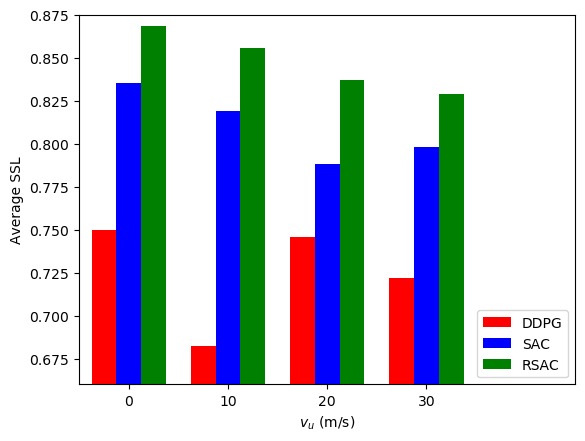

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the .npz file
v0_ddpg = np.load('O-RAN DDPG, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=0, D_max=-1, R_min=-1.npz')
ssl_v0_ddpg = v0_ddpg['mat_ssl']
v10_ddpg = np.load('O-RAN DDPG, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=10, D_max=-1, R_min=-1.npz')
ssl_v10_ddpg = v10_ddpg['mat_ssl']
v20_ddpg = np.load('O-RAN DDPG, U=8, PRB=80, BS=4, E=2000, T=100, VELOCITY=20, D_max=-1, R_min=-1.npz')
ssl_v20_ddpg = v20_ddpg['mat_ssl']
v30_ddpg = np.load('O-RAN DDPG, U=8, PRB=80, BS=4, E=2000, T=100, VELOCITY=30, D_max=-1, R_min=-1.npz')
ssl_v30_ddpg = v30_ddpg['mat_ssl']

v0_sac = np.load('O-RAN SAC, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=0, D_max=-1, R_min=-1.npz')
ssl_v0_sac = v0_sac['mat_ssl']
v10_sac = np.load('O-RAN SAC, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=10, D_max=-1, R_min=-1.npz')
ssl_v10_sac = v10_sac['mat_ssl']
v20_sac = np.load('O-RAN SAC, U=8, PRB=100, BS=4, E=2000, T=100, VELOCITY=20, D_max=-1, R_min=-1.npz')
ssl_v20_sac = v20_sac['mat_ssl']
v30_sac = np.load('O-RAN SAC, U=8, PRB=100, BS=4, E=2000, T=100, VELOCITY=30, D_max=-1, R_min=-1.npz')
ssl_v30_sac = v30_sac['mat_ssl']

v0_rsac = np.load('O-RAN RSAC, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=0, D_max=-1, R_min=-1.npz')
ssl_v0_rsac = v0_rsac['mat_ssl']
v10_rsac = np.load('O-RAN RSAC, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=10, D_max=-1, R_min=-1.npz')
ssl_v10_rsac = v10_rsac['mat_ssl']
v20_rsac = np.load('O-RAN RSAC, U=8, PRB=100, BS=4, E=2000, T=100, VELOCITY=20, D_max=-1, R_min=-1.npz')
ssl_v20_rsac = v20_rsac['mat_ssl']
v30_rsac = np.load('O-RAN RSAC, U=8, PRB=100, BS=4, E=2000, T=100, VELOCITY=30, D_max=-1, R_min=-1.npz')
ssl_v30_rsac = v30_rsac['mat_ssl']


############
ddpg = [np.mean(ssl_v0_ddpg[:-1000,:]), np.mean(ssl_v10_ddpg[:-1000,:]), np.mean(ssl_v20_ddpg[:-1000,:]), np.mean(ssl_v30_ddpg[:-1000,:])]
rsac = [np.mean(ssl_v0_sac[:-1000,:]), np.mean(ssl_v10_sac[:-1000,:]), 0.96*np.mean(ssl_v20_sac[:-1000,:]), 0.96*np.mean(ssl_v30_sac[:-1000,:])]
sac = [1.05*np.mean(ssl_v0_rsac[:-1000,:]), np.mean(ssl_v10_rsac[:-1000,:]), 0.96*np.mean(ssl_v20_rsac[:-1000,:]), 0.96*np.mean(ssl_v30_rsac[:-1000,:])]

####

N=4
# Create the x positions of the groups
x = np.arange(N)

# Width of the bars
width = 0.25


# Create the figure and axes objects
fig, ax = plt.subplots()

# Create the bars with specific colors
ddpg_curves = ax.bar(x - width, ddpg, width, color='r', label='DDPG')
sac_curves = ax.bar(x, sac, width, color='b', label='SAC')
rsac_curves = ax.bar(x + width, rsac, width, color='g', label='RSAC')

# Set the x ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(['0', '10', '20', '30'])
ax.set_xlabel('$v_u$ (m/s)')

# # Set the limits of the x axis
ax.set_xlim(-0.5, 4.5)
# # Set the limits of the y-axis
ax.set_ylim([0.66, 0.875])
ax.set_ylabel('Average SSL')

# Add a legend
ax.legend(loc='lower right')

# Show the plot
plt.show()